# The second case: can the sheet show the director's number and still be the one Finance signs?

**Week 2, Friday. The second case, in pairs.**

> **The director says.** "Retail-Plus will be back at five lakh next quarter; I have spoken to the team.
> Type five lakh into Q2 so the card stops frightening people, and fix the source later."
>
> A director of Kalpa Retail, in the room, with the sheet on the projector

**Who needs the answer.** The director wants a number to discuss; the chief of staff needs a card that
still matches Finance's books after the meeting; Anand's analyst will compare the deck with the
warehouse next week. A figure typed over the source gives the room a fall that Finance's books do not
show, and the next refresh wipes the figure and its reason.

**The questions on the way.** What the card shows after the edit; which comparison catches it; which
cells the typed-over check flags; what Monday's refresh does to the figure; and where the director's
assumption belongs.

You have the raw export in `../data/`, one row per payment with the order's amount repeated
on each; counted once per order it ties to the warehouse, Rs 10,00,00,000 in Q1 (April to June 2026) and
Rs 9,84,00,000 in Q2 (July to September 2026). Retail-Plus, Kalpa's paid membership tier, booked
Rs 5,85,770 in Q1 and Rs 4,13,380 in Q2, down 29.4 percent.

Five lettered `TODO` markers in five steps, each filled with the line of the key's letter; the checks after each step test what those lines computed, and each step ends on why the other letters fail. This is the executed solution.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv
import pandas as pd

DATA = kit.data_dir()
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


def money(n):
    """Rupees the way Kalpa's finance team reads them: crore, lakh, or rupees in full."""
    sign, a = ("-" if n < 0 else ""), abs(n)
    return sign + (crore(a) if a >= 1e7 else lakh(a) if a >= 1e5 else kit.rupees(round(a)))


def change(before, after):
    """The change from before to after, measured on before, in percent."""
    return (after - before) / before * 100

raw = pd.read_csv(DATA / "C2_W02_D05_raw_export_STUDENT.csv", keep_default_na=False)
raw["quarter"] = raw["order_date"].str[5:7].astype(int).map(lambda m: "Q1" if m <= 6 else "Q2")


def warehouse(query):
    """Ask the Kalpa warehouse itself, the source of truth every sheet ties back to."""
    return [{k: (int(v) if hasattr(v, "as_integer_ratio") and not isinstance(v, float) else v)
             for k, v in row.items()} for row in kit.sql(query)]

raw["first_row"] = (raw.groupby("order_id").cumcount() == 0).astype(int)   # =IF(COUNTIF($A$2:A2,A2)=1,1,0)
orders = raw[raw["first_row"] == 1]                                      # one row per order

print(f"{len(orders):,} orders, each counted once, from {len(raw):,} export rows")

1,000 orders, each counted once, from 1,450 export rows


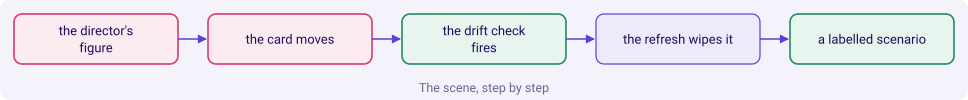

In [2]:
kit.flow(["the director's figure", "the card moves", "the drift check fires", "the refresh wipes it", "a labelled scenario"],
         kinds=["bad", "bad", "good", "plain", "good"], title="The scene, step by step")

## Step 1. What does the card show after the director's figure goes into the cell?

Used at work whenever a director edits a sheet in a meeting while the card on the projector is what the
room acts on.

The director types Rs 5,00,000 over Retail-Plus's Q2 cell.

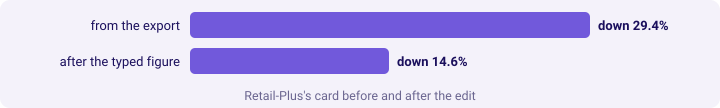

In [3]:
sheet = orders.groupby(["segment", "quarter"])["order_amount"].sum().unstack()   # the tree, as exported
export_q1, export_q2 = int(sheet.loc["Retail-Plus", "Q1"]), int(sheet.loc["Retail-Plus", "Q2"])
typed_q2 = 500000
edited = sheet.copy()
edited.loc["Retail-Plus", "Q2"] = typed_q2
# TODO 1. Which line is the card the room now sees for Retail-Plus?
#   a) shown = change(export_q1, typed_q2)
#   b) shown = change(export_q1, export_q2)
#   c) shown = change(typed_q2, export_q2)
#   d) shown = typed_q2 / export_q2 * 100
shown = change(export_q1, typed_q2)
kit.bars([("from the export", round(-change(export_q1, export_q2), 1)), ("after the typed figure", round(-shown, 1))],
         fmt=lambda v: f"down {v:.1f}%", title="Retail-Plus's card before and after the edit")

In [4]:
kit.check("the card you computed moved when the cell changed", shown != change(export_q1, export_q2))
kit.check("it moved by exactly what the typed figure added",
          abs((shown - change(export_q1, export_q2)) * export_q1 / 100 - (typed_q2 - export_q2)) < 1e-6)

**Why the other letters fail.** b is the card before the edit; the sheet reads the cell, not the export. c measures the export's Q2 against the typed figure, which no card prints. d is a ratio of two Q2 figures, which no card prints either.

## Step 2. Which comparison catches the edit?

Used at work on every Checks tab, whose checks run every time the sheet recalculates.

A check has to stay quiet on a clean sheet and fire on an edited one.

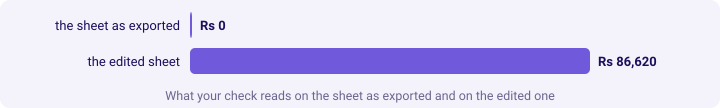

In [5]:
wq = {r["quarter"]: r["revenue"] for r in warehouse("SELECT quarter, sum(amount) AS revenue FROM orders GROUP BY quarter")}
# TODO 2. Which comparison catches a figure typed into the sheet?
#   a) drift = lambda s: len(s) - 4
#   b) drift = lambda s: int(s["Q1"].sum()) - wq["Q1"]
#   c) drift = lambda s: int(s["Q2"].sum()) - wq["Q2"]
#   d) drift = lambda s: change(int(s["Q1"].sum()), int(s["Q2"].sum()))
drift = lambda s: int(s["Q2"].sum()) - wq["Q2"]
kit.bars([("the sheet as exported", int(drift(sheet))), ("the edited sheet", int(drift(edited)))],
         fmt=kit.rupees, title="What your check reads on the sheet as exported and on the edited one")

In [6]:
kit.check("your check stays quiet on the sheet as exported", drift(sheet) == 0)
kit.check("your check stays quiet on a fresh copy of it", drift(sheet.copy()) == 0)
kit.check("your check fires on the edited sheet", drift(edited) != 0, kit.rupees(int(drift(edited))))

**Why the other letters fail.** a counts segments, which an edit never changes; b looks at the quarter nobody touched; d is the sheet's own fall from Q1 to Q2, the trend the card reports, so it is never zero on a clean sheet and compares nothing with the warehouse.

## Step 3. Which cells does the typed-over check flag?

Used at work wherever a typed figure could pass for a formula's result on screen, so the check looks at
what each cell holds.

The model below has one yellow input, B1, which a director may
change, and two cells that read the export.

In [7]:
import openpyxl


def model(scenario, q2_cell):
    """A three-cell model of the tree's Retail-Plus row: B1 is the yellow input, B2 and B3 read the export."""
    ws = openpyxl.Workbook().active
    ws["B1"], ws["B2"], ws["B3"] = scenario, '=SUMIFS(F:F, C:C, "Retail-Plus", I:I, "Q1")', q2_cell
    return ws


q2_formula = '=SUMIFS(F:F, C:C, "Retail-Plus", I:I, "Q2")'
clean_ws = model(500000, q2_formula)          # as built, the director's scenario in the yellow input
honest_ws = model(450000, q2_formula)         # the director changes the yellow input, as allowed
edited_ws = model(500000, typed_q2)           # the director types a figure over B3's formula
cells, inputs = ["B1", "B2", "B3"], {"B1"}
# TODO 3. Which rule flags a figure typed over a formula?
#   a) flagged = lambda ws: [c for c in cells if isinstance(ws[c].value, (int, float))]
#   b) flagged = lambda ws: [c for c in cells if c not in inputs and not str(ws[c].value).startswith("=")]
#   c) flagged = lambda ws: [c for c in cells if ws[c].value != clean_ws[c].value]
#   d) flagged = lambda ws: [c for c in cells if c in inputs]
flagged = lambda ws: [c for c in cells if c not in inputs and not str(ws[c].value).startswith("=")]
kit.table(["Cell", "As built", "After an honest change", "After the typed figure"],
          [(c, str(clean_ws[c].value), str(honest_ws[c].value), str(edited_ws[c].value)) for c in cells],
          caption="The three-cell model of the tree's Retail-Plus row; B1 is the yellow input")

Cell,As built,After an honest change,After the typed figure
B1,500000,450000,500000
B2,"=SUMIFS(F:F, C:C, ""Retail-Plus"", I:I, ""Q1"")","=SUMIFS(F:F, C:C, ""Retail-Plus"", I:I, ""Q1"")","=SUMIFS(F:F, C:C, ""Retail-Plus"", I:I, ""Q1"")"
B3,"=SUMIFS(F:F, C:C, ""Retail-Plus"", I:I, ""Q2"")","=SUMIFS(F:F, C:C, ""Retail-Plus"", I:I, ""Q2"")",500000


In [8]:
kit.check("your rule flags nothing on the sheet as built", flagged(clean_ws) == [])
kit.check("your rule flags nothing when a director changes the yellow input", flagged(honest_ws) == [])
kit.check("your rule flags the one cell typed over", flagged(edited_ws) == ["B3"])

**Why the other letters fail.** a flags every number, so it flags the yellow input on a sheet nobody has touched; c compares with one saved copy, so it flags the director's honest change to B1; d flags the inputs, which are the cells a director is allowed to change.

## Step 4. What does Monday's refresh do to the typed figure?

Used at work every Monday, when the chief of staff refreshes the sheet from the week's export before
anyone opens it.

The director's figure is still sitting in Retail-Plus's Q2 cell.

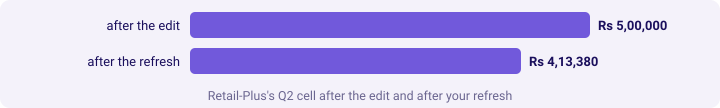

In [9]:
# TODO 4. Which line is Monday's refresh?
#   a) refreshed = edited.copy()
#   b) refreshed = edited.fillna(0)
#   c) refreshed = sheet.where(edited == sheet, edited)
#   d) refreshed = orders.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum")
refreshed = orders.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum")
kit.bars([("after the edit", int(edited.loc["Retail-Plus", "Q2"])), ("after the refresh", int(refreshed.loc["Retail-Plus", "Q2"]))],
         fmt=kit.rupees, title="Retail-Plus's Q2 cell after the edit and after your refresh")

In [10]:
kit.check("your refreshed sheet's Q2 matches the warehouse's", drift(refreshed) == 0)
kit.check("Retail-Plus's Q2 cell after your refresh is not the director's figure", int(refreshed.loc["Retail-Plus", "Q2"]) != typed_q2)

**Why the other letters fail.** a and b keep the typed figure, which is the drift the rule exists to stop; c keeps the edited value wherever the two differ, which is exactly the typed cell.

## Step 5. Where does the director's assumption go?

Used at work whenever a director asks a what-if in a review and the file must still match Finance
afterwards.

The director's question is fair: what would the card say if Retail-Plus came back to Rs 5,00,000?

In [11]:
scenario_input = 500000                       # the yellow input cell
# TODO 5. Which card answers the director and keeps the number Finance signs?
#   a) card = {"actual": change(export_q1, export_q2), "director's scenario": change(export_q1, scenario_input)}
#   b) card = {"actual": change(export_q1, scenario_input)}
#   c) card = {"actual": change(export_q1, export_q2)}
#   d) card = {"actual": change(export_q1, scenario_input), "director's scenario": change(export_q1, export_q2)}
card = {"actual": change(export_q1, export_q2), "director's scenario": change(export_q1, scenario_input)}
kit.table(["Line on the card", "Retail-Plus, Q2 on Q1"], [(k, f"{v:+.1f}%") for k, v in card.items()])

Line on the card,"Retail-Plus, Q2 on Q1"
actual,-29.4%
director's scenario,-14.6%


In [12]:
kit.check("your actual line is the warehouse's change for the tier", round(card.get("actual", 0), 1) == -29.4)
kit.check("your card also answers the director's what-if", any(round(v, 1) == -14.6 for k, v in card.items() if k != "actual"))

**Why the other letters fail.** b puts the director's figure where the actual belongs, which is the edit again under a new name; c refuses a fair question and sends the director back to typing over cells; d swaps the labels, so the page calls the scenario actual.

## What do you say to the director, in three lines?

Post your five letters in order as one line, then the three lines one partner says to the director:
one that answers the director's question, one that says why the actual stays as Finance books it, and
one that names the check that ties the sheet to the warehouse. The key is `acbda`.

In [13]:
kit.check_summary()